#Before Code Explanation

So before even starting we wanted to explain the goal of this project with the explanation of how everything works as we go. We set up a few regression models to predict what users would rate movies, but we wanted to go deeper and make a Netflix style collaborative filtering model. The goal isn't to copy netflix recommnedation systems, it's more so to see if we can predict accurately whether users will like movies based on their previous ratings, data on the movie (genre, avg rating, etc.), and behavioral analysis. So first lets dive into how collaborative filtering really works.

#Collaborative Filtering Explanation

Collaborative Filtering is basically looking at what people liked and if you liked something similar to them, then it can make the assumption that you liked another thing that your "co-liker" enjoyed.

For Example:
Imagine three users:

User 1:
- Inception → 5⭐
- Interstellar → 5⭐

User 2:
- Inception → 5⭐
- Interstellar → 4⭐

User 3:
- Inception → 5⭐
- Interstellar → ? (not watched yet)

From this, we can see:
- User 1 and User 2 have very similar taste
- Both liked Inception and Interstellar

So if User 3 also liked Inception…

The system can infer:
→ User 3 will probably like Interstellar too

Even though:
- We didn't use genres
- We didn't use actors
- We didn't use any movie features

We only used it's just making inference on behavior of people who can be deemed similar to you.

#Why Collaborative Filtering Improves Analysis


This approach is powerful because:

- It captures **hidden patterns** (taste, mood, style)
- It doesn't rely on manually created features
- It adapts as more users interact with content

This is how platforms like Netflix, Spotify, and Amazon:
- Recommend movies
- Suggest songs
- Show products

They are not just analyzing content —
they are learning from **millions of user interactions**.

The issue with collaborative filtering alone is that the user has little to no ratings, collaborative filtering alone won't be enough to help with recommendations. That's where a hybrid model with machine learning can help us.

#Hybrid Model

To solve this, we introduce a **hybrid recommendation system**.

Instead of relying on just one method, we combine:

- **Collaborative Filtering (SVD)**  
  → learns patterns from user behavior and similarities  

- **Machine Learning (Regression Models)**  
  → uses structured features like:
  - user rating behavior  
  - movie popularity  
  - genre preferences  


To build the regression component of our hybrid system, we will experiment with multiple models:

- **Ridge Regression**  
  → serves as a baseline linear model with regularization  

- **Random Forest Regressor**  
  → captures non-linear relationships and interactions between features  

- **XGBoost Regressor**  
  → a powerful gradient boosting model that handles complex patterns in tabular data  

We will compare these models using RMSE and select the best-performing one to integrate into our hybrid recommendation system.


By combining the strongest regression model with collaborative filtering,  
we aim to build a system that captures both:

- **explicit preferences** (features and ratings)  
- **implicit patterns** (user behavior and similarity)


Now that the reasoning behind the hybrid recommendation system has been established, the next step is to begin building each component. We will start with collaborative filtering using SVD, then evaluate several regression models, and finally combine them into a hybrid system.

#THE CODE STARTS HERE

#SVD explanation before anything




Matrix factorization is a way of breaking down a large user–movie rating matrix into smaller representations that capture hidden patterns in user preferences and movie characteristics.

Instead of directly analyzing all ratings, it learns latent factors, which are hidden dimensions of taste, like preference for certain types of movies.

Each user is represented as a vector of preferences, and each movie is represented as a vector of characteristics. The model then predicts ratings based on how well those vectors align.

SVD is a specific method used to perform this matrix factorization. It learns these user and movie vectors from the data and uses them to estimate missing ratings, which helps generate recommendations.



To better understand how matrix factorization works, we can think of both users and movies as vectors of hidden (latent) features.

For example:

- User 1 = [0.95, 0.60]  
- Movie A (Interstellar) = [0.95, 0.57]  
- Movie B (Toy Story) = [0.20, 0.90]  

Each number represents a **latent factor**, which captures hidden aspects of taste and movie characteristics.

---



To predict how much a user will like a movie, we compare their vectors using a dot product.

For User 1 and Movie A:

(0.95 × 0.95) + (0.60 × 0.57)  
= 0.9025 + 0.342  
= 1.2445  

For User 1 and Movie B:

(0.95 × 0.20) + (0.60 × 0.90)  
= 0.19 + 0.54  
= 0.73  

---



- Movie A has a **higher score**, so it is a better match for User 1  
- Movie B has a lower score, so it is less aligned with User 1’s preferences  

---



The model recommends movies by finding the ones with the **highest match scores**.

In simple terms:

> The better the alignment between a user’s preference vector and a movie’s characteristic vector, the higher the predicted rating.

This is how matrix factorization allows us to estimate ratings and generate recommendations, even when a user has not seen a movie before.

#Packages Necessary

We use Surprise because it’s built specifically for recommendation systems and makes implementing SVD for collaborative filtering much easier. I will also use XGBoost later so I'll download it now. I had to go back and add the numpy to less than 2 so it works.

In [2]:

!pip install scikit-surprise
!pip install xgboost
!pip install "numpy<2"

#Libraries Needed

This is just set up of the libraries that we will be using later.

In [3]:
#The og setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Recommendation system (SVD) for collaborative filteringu
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split

# Machine learning models (for later hybrid step)
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

#I will use this for the evaluations of the ML models
from sklearn.metrics import mean_squared_error

#Google Drive

We don't want to go about the round about set up of creating a upload button for the files, so we'll just connect the google drive and them in here for the cleaning of the dataset.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Instead of uploading all the files individually we can set up a base path and add them in like that with just a + "filename"

In [5]:
base_path = "/content/drive/MyDrive/Movie_Predictor/"

In [6]:
movies = pd.read_csv(base_path + "movies.csv")
ratings = pd.read_csv(base_path + "ratings.csv")

#Dataset Details

We wanted to see if the files are good to go for the cleaning so a quick look should be good enough.

In [7]:
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)


Movies shape: (87585, 3)
Ratings shape: (32000204, 4)


Shape only gives you so much let me look at the first 5 entries of both to see what we are working with.

In [8]:
ratings.head()


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


The other columns look good but the timestamp might be irrelevant for the EDA.

In [9]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [10]:
df = ratings.merge(movies, on="movieId", how="left")

df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,17,4.0,944249077,Sense and Sensibility (1995),Drama|Romance
1,1,25,1.0,944250228,Leaving Las Vegas (1995),Drama|Romance
2,1,29,2.0,943230976,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
3,1,30,5.0,944249077,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
4,1,32,5.0,943228858,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller


In [11]:
df = df.drop(columns=["timestamp"])

Sample so that it doesn't crash.

In [12]:
sample_user = df["userId"].drop_duplicates().sample(5000, random_state=42)
df = df[df["userId"].isin(sample_user)].copy()
df.head()

,userId,movieId,rating,title,genres
367,5,10,4.0,GoldenEye (1995),Action|Adventure|Thriller
368,5,47,3.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
369,5,110,4.0,Braveheart (1995),Action|Drama|War
370,5,150,3.0,Apollo 13 (1995),Adventure|Drama|IMAX
371,5,153,3.0,Batman Forever (1995),Action|Adventure|Comedy|Crime


We also need to filter ratings in order to match the users we sampled

In [13]:
ratings_sample = ratings[ratings["userId"].isin(sample_user)]

print("Sample ratings shape:", ratings_sample.shape)
ratings_sample.head()

Sample ratings shape: (789872, 4)


,userId,movieId,rating,timestamp
367,5,10,4.0,840768638
368,5,47,3.0,840768897
369,5,110,4.0,840768763
370,5,150,3.0,840763914
371,5,153,3.0,840764018


#Merge

We can use all of these let's merge the two datasets on the movieId then we can clean it up a little before the EDA.

In [14]:
#Remove the timestamp since it's irrelevant
df = ratings_sample[["userId", "movieId", "rating"]].merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

print("Merged sample shape:", df.shape)
df.head()

Merged sample shape: (789872, 5)


,userId,movieId,rating,title,genres
0,5,10,4.0,GoldenEye (1995),Action|Adventure|Thriller
1,5,47,3.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
2,5,110,4.0,Braveheart (1995),Action|Drama|War
3,5,150,3.0,Apollo 13 (1995),Adventure|Drama|IMAX
4,5,153,3.0,Batman Forever (1995),Action|Adventure|Comedy|Crime


#Split the genres

Now we need to split the genres so that it is able to understand how the genres and combos of genre's effect user rating.

In [15]:
df["genre_list"] = df["genres"].str.split("|")

df[["title", "genres", "genre_list"]].head()

,title,genres,genre_list
0,GoldenEye (1995),Action|Adventure|Thriller,"[Action, Adventure, Thriller]"
1,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,"[Mystery, Thriller]"
2,Braveheart (1995),Action|Drama|War,"[Action, Drama, War]"
3,Apollo 13 (1995),Adventure|Drama|IMAX,"[Adventure, Drama, IMAX]"
4,Batman Forever (1995),Action|Adventure|Comedy|Crime,"[Action, Adventure, Comedy, Crime]"


Now lets drop the original genres column and list out all the genres for a better EDA.

In [16]:
df = df.drop(columns=["genres"])

#Encoding for genres


Now that we have removed the original `genres` column, we will encode the `genre_list` into numerical features.

The goal is to transform each movie’s list of genres into individual binary columns. For example:

- Action = 1  
- Adventure = 1  
- Thriller = 1  
- Comedy = 0  

This process is part of **feature engineering**, where we convert raw data into a format that machine learning models can understand.

Machine learning models cannot work directly with lists or text-based data. Instead, they require numerical inputs. By encoding genres as 0s and 1s, we allow the model to:

- identify which genres a movie belongs to  
- learn how different genres influence user ratings  
- capture patterns in user preferences  

In simple terms:

> We are turning a list of genres into structured numerical features so the model can learn from them effectively.

In [17]:
genre_dummies = pd.get_dummies(df["genre_list"].explode()).groupby(level=0).sum()

df = pd.concat([df, genre_dummies], axis=1)

print("Shape after encoding genres:", df.shape)
df.head()

Shape after encoding genres: (789872, 25)


,userId,movieId,rating,title,genre_list,(no genres listed),Action,Adventure,Animation,Children,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,5,10,4.0,GoldenEye (1995),"[Action, Adventure, Thriller]",0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,5,47,3.0,Seven (a.k.a. Se7en) (1995),"[Mystery, Thriller]",0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2,5,110,4.0,Braveheart (1995),"[Action, Drama, War]",0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,5,150,3.0,Apollo 13 (1995),"[Adventure, Drama, IMAX]",0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
4,5,153,3.0,Batman Forever (1995),"[Action, Adventure, Comedy, Crime]",0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


#Final Check Before EDA

Just checking if there are any missings or duplicates before I start looking through the data.

In [18]:
df.isnull().sum().sort_values(ascending=False).head(30)

,0
userId,0
Drama,0
War,0
Thriller,0
Sci-Fi,0
Romance,0
Mystery,0
Musical,0
IMAX,0
Horror,0


In [19]:
duplicates = df.drop(columns=["genre_list"]).duplicated().sum()
print("The Dups:", duplicates)

The Dups: 0


We look to be good to go with the EDA now let me map out what I want to see with the data analysis. Probably just regular averages, genre performance, user ratings. After looking at that we will go from data analytics to real modeling in SVD.

#The EDA (THE REAL CODE STARTS HERE)

We look to be good to go with the EDA now let me map out what I want to see with the data analysis. Probably just regular averages, genre performance, user ratings. After looking at that we will go from data analytics to real modeling in SVD.

One last look at data quality and we start.

### Data Quality Check

Everything looks clean going into EDA. There are no missing values across any columns, and after checking for duplicates (excluding the genre_list column), there are no duplicate rows either.

The dataset has about 790K ratings from 5,000 users across ~24K movies, which is a solid sample to work with. It’s big enough to see real patterns in user behavior and movie performance, but still manageable to run analysis and models quickly.

Overall, the data is in a good spot, so we can move straight into understanding how users rate movies, how active they are, and how different genres perform before building any models.

In [20]:

# Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
print("Missing Values:", missing_values.head(30))

# Duplicate check (exclude genre_list due to list-type structure)
duplicates = df.drop(columns=["genre_list"]).duplicated().sum()
print("Duplicate Rows:", duplicates)

# Basic structure check
print("Dataset Shape:", df.shape)
print("Unique Users:", df["userId"].nunique())
print("Unique Movies:", df["movieId"].nunique())
print("Total Ratings:", len(df))

Missing Values: userId                0
Drama                 0
War                   0
Thriller              0
Sci-Fi                0
Romance               0
Mystery               0
Musical               0
IMAX                  0
Horror                0
Film-Noir             0
Fantasy               0
Documentary           0
movieId               0
Crime                 0
Comedy                0
Children              0
Animation             0
Adventure             0
Action                0
(no genres listed)    0
genre_list            0
title                 0
rating                0
Western               0
dtype: int64
Duplicate Rows: 0
Dataset Shape: (789872, 25)
Unique Users: 5000
Unique Movies: 24437
Total Ratings: 789872


##Rating Distribution



In [21]:
df["rating"].describe()

,rating
count,789872.000000
mean,3.535279
std,1.079445
min,0.500000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


In [22]:
df["rating"].value_counts().sort_index()

,count
rating,
0.5,16311
1.0,23908
1.5,13147
2.0,49393
2.5,40489
3.0,144927
3.5,106053
4.0,206758
4.5,73607


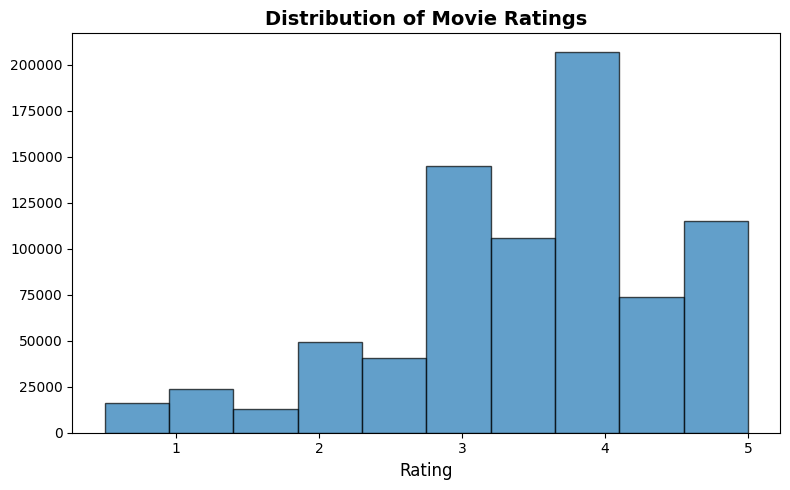

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["rating"], bins=10, edgecolor="black", alpha=0.7)

plt.title("Distribution of Movie Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating", fontsize=12)
plt.ylabel("")  # removes "Frequency" label

plt.tight_layout()
plt.show()


Looking at the rating distribution, most ratings are concentrated between 3.0 and 4.5, with 4.0 being the most common rating by a wide margin. Lower ratings (below 2.5) are much less frequent, which shows that users tend to rate movies more leniently.

This creates a clear positive bias in the dataset, where users are more likely to rate movies they enjoy rather than ones they dislike. Because of this, there is less variation in ratings, which can make it harder for models to clearly distinguish between average and highly preferred movies.

This bias will be important to account for when building baseline and collaborative filtering models, as user and item-level adjustments may be needed.

## Sparsity Analysis

What is sparsity analysis?

The best way to explain sparsity in terms of a dataset is the amount of data that you are missing in the matrix. In terms of the movies that we have in this dataset most people will have no ratings for them. So sparsity analysis is trying to look at the all the possible ratings you can have and what you actually got from the dataset. So lets say we have 5,000 users and 24,000 movies. You can end up with 120,000,000 ratings total if all the users rated all the movies, however it would more than likely be less ratings 790,000 in our case. We will use this to understand what we need to do before we model.

In [24]:
# Basic counts
n_users = df["userId"].nunique()
n_movies = df["movieId"].nunique()
n_ratings = len(df)

print("Number of ratings:", n_ratings)
print("Number of movies:",n_movies)
print("Number of users:",n_users)

Number of ratings: 789872
Number of movies: 24437
Number of users: 5000


There looks to be millions of ratings missing, but that's okay lets dive a little deeper.

In [25]:
# Total possible interactions
total_possible = n_users * n_movies

# Sparsity calculation
sparsity = 1 - (n_ratings / total_possible)

# Density calculation
density = n_ratings / total_possible

print("Total possible movie ratings:", total_possible)
print("Number of rating in the set:", n_ratings)
print("Sparsity of the dataset:", round(sparsity * 100, 3), "%")
print("Density of the dataset:", round(density * 100, 3), "%")

Total possible movie ratings: 122185000
Number of rating in the set: 789872
Sparsity of the dataset: 99.354 %
Density of the dataset: 0.646 %


In [26]:

# Convert to percentages for visualization
present = density * 100
missing = sparsity * 100

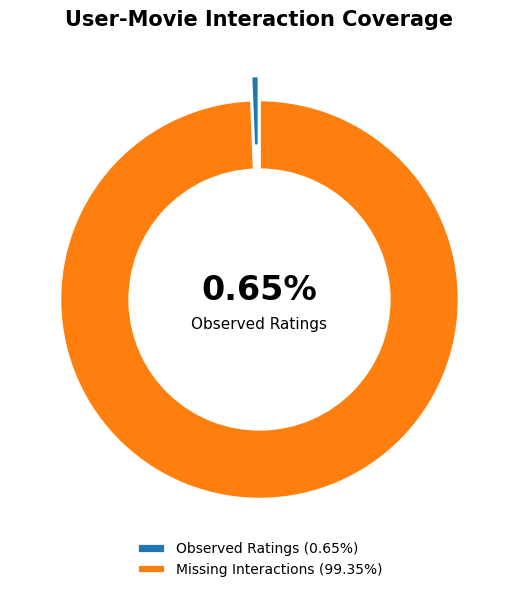

In [27]:
import matplotlib.pyplot as plt

labels = ["Observed Ratings", "Missing Interactions"]
values = [present, missing]

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts = ax.pie(
    values,
    labels=None,                # no labels on slices
    startangle=90,
    explode=(0.12, 0),
    wedgeprops={"width": 0.35, "edgecolor": "white", "linewidth": 2}
)

ax.set_title("User-Movie Interaction Coverage", fontsize=15, fontweight="bold", pad=18)

# Center annotation (keep this — it's clean)
ax.text(
    0, 0.05,
    f"{present:.2f}%",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax.text(
    0, -0.12,
    "Observed Ratings",
    ha="center",
    va="center",
    fontsize=11
)

# Legend (this is where labels live now)
ax.legend(
    wedges,
    [f"{labels[0]} ({present:.2f}%)", f"{labels[1]} ({missing:.2f}%)"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=1,
    frameon=False
)

plt.tight_layout()
plt.show()

Based on the calculations, only about 0.65% of all possible user–movie interactions actually exist, meaning over 99% of the matrix is missing. This confirms that the dataset is extremely sparse, which is expected in recommendation systems.

Because of this, most users have only rated a small number of movies, and most movies have very few ratings. This limits direct comparisons between users and makes it harder for models to learn relationships from overlapping data.

Given this, the next step is to take a closer look at how ratings are distributed across users and movies. Specifically, we want to understand which users are contributing most of the data and which movies have enough interactions to be meaningful.

This will help us identify long-tail patterns and determine how much of the dataset is actually useful before moving into modeling.

##User Activity

In [28]:
user_activity = df.groupby("userId").size()

print(user_activity.describe())

count    5000.000000
mean      157.974400
std       260.579002
min        20.000000
25%        35.000000
50%        73.000000
75%       171.000000
max      5061.000000
dtype: float64


Looking at user activity, there is a clear imbalance in how users contribute ratings. On average, users have rated about 158 movies, but the median is much lower at 73, which shows that the data is skewed by a smaller group of highly active users.

Most users fall within a lower range of activity, with 25% of users having fewer than 35 ratings and 50% having fewer than 73. At the same time, there are some extremely active users, like who is having over 5,000 ratings that person is a cinephile.

This tells us that a large portion of the data is being driven by a smaller group of power users, while the majority of users have more limited interaction histories. From a modeling perspective, this is important because collaborative filtering will learn stronger patterns from highly active users, while users with fewer ratings will be harder to model accurately.

##Movie Popularity Analysis

In [29]:
movie_popularity = df.groupby("movieId").size()

print(movie_popularity.describe())

count    24437.000000
mean        32.322789
std        116.789071
min          1.000000
25%          1.000000
50%          2.000000
75%         13.000000
max       2528.000000
dtype: float64


Looking at movie popularity, we see an even stronger imbalance than on the user side. On average, movies receive about 32 ratings, but the median is only 2, which shows that most movies have very little interaction data.

In fact, 25% of movies have only 1 rating, and 50% have 2 or fewer ratings. This means that the majority of movies in the dataset have almost no user interaction history. At the same time, a small number of movies are extremely popular, with some having over 2,500 ratings.

This confirms a clear long-tail distribution where a handful of popular movies dominate the dataset, while most movies sit in the tail with very limited data.

From a modeling perspective, this is important because collaborative filtering relies on interaction data to learn patterns. Popular movies with many ratings will have strong signals, while the majority of movies will be much harder to recommend accurately due to the lack of data.

##Low Activity Analysis

In [30]:
# % of low-activity users
low_user_pct = (user_activity < 20).mean()

# % of low-interaction movies
low_movie_pct = (movie_popularity < 5).mean()

print(f"Users with <20 ratings: {low_user_pct:.2%}")
print(f"Movies with <5 ratings: {low_movie_pct:.2%}")

Users with <20 ratings: 0.00%
Movies with <5 ratings: 60.58%


Looking at low-activity thresholds, the user side of the dataset is actually in a good position. All users have at least 20 ratings, which provides enough interaction history to learn meaningful user preferences.

The issue is clearly on the movie side. Around 60% of movies have fewer than 5 ratings, meaning the majority of movies have very limited interaction data. This confirms that the sparsity in the dataset is primarily being driven by the item side rather than the user side.

For now, we are not removing these low-interaction movies. Instead, we want to understand how much they impact the overall structure of the dataset and the modeling process.

Later on, we can test whether filtering out these low-signal movies improves model performance. But at this stage, the goal is to fully understand the data before making any decisions about what to keep or remove.

## Genre-Based Analysis

Since many movies have very limited interaction data, the next step is to explore whether content-based features like genres can provide additional signal and help improve recommendations, especially for low-interaction movies.

In [31]:

genre_cols = ['Action','Comedy','Drama','Sci-Fi','Romance','Thriller',
              'Adventure','Animation','Children','Crime','Fantasy',
              'Horror','Mystery','War','Western','IMAX','Musical','Film-Noir','Documentary']

genre_avg = {}

for col in genre_cols:
    genre_avg[col] = df[df[col] == 1]["rating"].mean()

import pandas as pd

genre_df = pd.DataFrame.from_dict(genre_avg, orient="index", columns=["avg_rating"])
genre_df = genre_df.sort_values("avg_rating", ascending=False)

genre_df

,avg_rating
Film-Noir,3.928678
War,3.797993
Crime,3.697766
Documentary,3.683801
Drama,3.681986
Mystery,3.672408
IMAX,3.603674
Animation,3.596137
Western,3.559876
Musical,3.539507


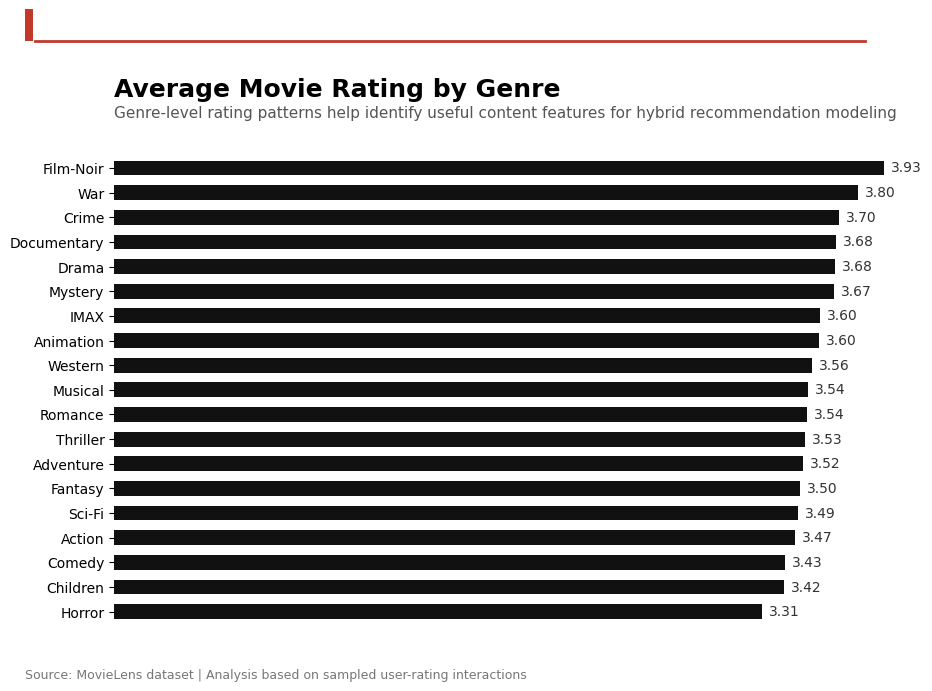

In [32]:
import matplotlib.pyplot as plt

plot_df = genre_df.sort_values("avg_rating", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

# Bars (slightly thinner)
bars = ax.barh(
    plot_df.index,
    plot_df["avg_rating"],
    color="#111111",
    height=0.6
)

# Bar labels
ax.bar_label(
    bars,
    labels=[f"{x:.2f}" for x in plot_df["avg_rating"]],
    padding=5,
    fontsize=10,
    color="#333333"
)

# Title
ax.set_title(
    "Average Movie Rating by Genre",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=30
)

# Subtitle (more spacing + softer tone)
ax.text(
    0,
    1.04,
    "Genre-level rating patterns help identify useful content features for hybrid recommendation modeling",
    transform=ax.transAxes,
    fontsize=11,
    color="#555555"
)

# Remove clutter
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.grid(False)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Softer accent (thinner + slightly muted red)
fig.patches.extend([
    plt.Rectangle(
        (0.08, 0.93),
        0.008,
        0.045,
        transform=fig.transFigure,
        color="#c0392b",
        clip_on=False,
        linewidth=0
    )
])

ax.plot(
    [0.09, 0.92],
    [0.93, 0.93],
    transform=fig.transFigure,
    color="#c0392b",
    linewidth=2,
    clip_on=False
)

# Footnote (lighter)
fig.text(
    0.08,
    0.02,
    "Source: MovieLens dataset | Analysis based on sampled user-rating interactions",
    fontsize=9,
    color="#777777"
)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.9])
plt.show()

The genre-level analysis shows that while rating differences are not extreme, there is a clear and consistent pattern in user preferences. Certain genres such as Film-Noir, War, and Crime tend to receive higher ratings, while others like Horror and Children consistently fall on the lower end.

This indicates that user behavior is partially driven by content characteristics, not just interaction patterns. Even small but consistent differences like these can provide meaningful signal in a recommendation system.

Given the large number of low-interaction movies identified earlier, genre features become especially valuable. They allow the model to infer similarities between movies even when direct user interaction data is limited.

This reinforces the use of hybrid modeling approaches, where collaborative filtering is supplemented with content-based features to improve recommendation quality across both popular and long-tail items.

Now it's time to start with the SVD model.

#SVD Model (THE REALER CODE)

In order to run the SVD all we really need are the users, movies and the ratings.

In [33]:
svd_df = df[["userId", "movieId", "rating"]].copy()

print(svd_df.shape)
svd_df.head()

(789872, 3)


,userId,movieId,rating
0,5,10,4.0
1,5,47,3.0
2,5,110,4.0
3,5,150,3.0
4,5,153,3.0


We should also look at the min and the max of the ratings to know what the model should be predicting off of.

In [34]:
print(svd_df["rating"].min())
print(svd_df["rating"].max())

0.5
5.0


The way that surprise works is that it needs to be able to understand your ratings and we do that with the reader function giving it the scale from .5 to 5 stars. It also neeeds to be able to take your dataframe and make sure it makes sense for the Singular Value Decomposition.

In [35]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(
    svd_df[["userId", "movieId", "rating"]],
    reader
)

You are giving surprise something that it can make a matrix from so that SVD can learn the similaries between users.

Example:

|        | Movie A | Movie B | Movie C |
| ------ | ------- | ------- | ------- |
| User 1 | 4.0     | 3.5     | ?       |
| User 2 | 5.0     | ?       | ?       |
| User 3 | ?       | 4.0     | 2.5     |


Basically we said take all my ratings and convert them into the internal matrix format so SVD can train. Just like the example above that it is what we are prepping it to look like so the SVD can find hidden preference pattern between users and movies.

In [36]:
trainset = data.build_full_trainset()
print("Number of users:", trainset.n_users)
print("Number of items:", trainset.n_items)

Number of users: 5000
Number of items: 24437


We split the data into 80% training (631,897 ratings) and 20% testing (157,975 ratings) so the model can learn patterns from one portion of the data and be evaluated on unseen data. This ensures the model is not just memorizing ratings, but actually learning user preferences that generalize to new interactions.

In [37]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("Train size:", trainset.n_ratings)
print("Test size:", len(testset))

Train size: 631897
Test size: 157975


In this step, we trained a model that looks at how users rated movies and learns patterns in what people like. It keeps adjusting itself until it can guess ratings as close as possible to the real ones.

In [38]:
from surprise import SVD

model = SVD()

model.fit(trainset)

In [39]:
from surprise import accuracy

predictions = model.test(testset)
rmse = accuracy.rmse(predictions)

RMSE: 0.8511


We tested how good the model’s predictions are, and on average it is about 0.85 stars off from the real ratings, which is pretty accurate.

Now let's take a look on the user performance and see if we are close.

In [40]:
user_id = svd_df["userId"].iloc[0]
user_id

5

We'll be using user number 5.


In [41]:
movies_rated_by_user = svd_df[svd_df["userId"] == user_id]["movieId"].unique()

print("Movies already rated:", len(movies_rated_by_user))

Movies already rated: 33


We want to test on the movies he rated.

In [42]:
user_actuals = svd_df[svd_df["userId"] == user_id][["movieId", "rating"]].copy()

user_actuals.head()

,movieId,rating
0,10,4.0
1,47,3.0
2,110,4.0
3,150,3.0
4,153,3.0


In [43]:
predictions = []

for _, row in user_actuals.iterrows():
    pred = model.predict(user_id, row["movieId"])
    predictions.append((row["movieId"], row["rating"], pred.est))

user_eval = pd.DataFrame(
    predictions,
    columns=["movieId", "actual_rating", "predicted_rating"]
)

The way this works is we are making a empty list for our results with predictions = []   then we look through all the user_actual ratings movie_ids with for _, row in user_actuals.iterrows():  iterrow basically tells it to do row by row. After we then go through all of the movie_ids and use our model to predict what the user would rate it based on our SVD with pred = model.predict(user_id, row["movieID]). After that we append the movieID, rating, and prediction into our predictions list. Then we can finally take our list predictions and convert it into a dataframe with pandas DataFrame function. It is listed at user_eval.

In [44]:
user_eval = user_eval.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

user_eval.head()

,movieId,actual_rating,predicted_rating,title,genres
0,10.0,4.0,3.658226,GoldenEye (1995),Action|Adventure|Thriller
1,47.0,3.0,3.434375,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
2,110.0,4.0,3.650809,Braveheart (1995),Action|Drama|War
3,150.0,3.0,4.032118,Apollo 13 (1995),Adventure|Drama|IMAX
4,153.0,3.0,3.023776,Batman Forever (1995),Action|Adventure|Comedy|Crime


Here we just do a left join from our user_eval dataframe onto our movies table on the movieID.

In [45]:
user_eval["error"] = user_eval["actual_rating"] - user_eval["predicted_rating"]

user_eval.head()

,movieId,actual_rating,predicted_rating,title,genres,error
0,10.0,4.0,3.658226,GoldenEye (1995),Action|Adventure|Thriller,0.341774
1,47.0,3.0,3.434375,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,-0.434375
2,110.0,4.0,3.650809,Braveheart (1995),Action|Drama|War,0.349191
3,150.0,3.0,4.032118,Apollo 13 (1995),Adventure|Drama|IMAX,-1.032118
4,153.0,3.0,3.023776,Batman Forever (1995),Action|Adventure|Comedy|Crime,-0.023776


This is just a simple error calculation to see how far we were off on some movies.

In [46]:
user_eval.sort_values("error").head(10)

,movieId,actual_rating,predicted_rating,title,genres,error
15,318.0,1.0,4.149211,"Shawshank Redemption, The (1994)",Crime|Drama,-3.149211
13,296.0,1.0,3.586831,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,-2.586831
10,253.0,2.0,3.073959,Interview with the Vampire: The Vampire Chroni...,Drama|Horror,-1.073959
3,150.0,3.0,4.032118,Apollo 13 (1995),Adventure|Drama|IMAX,-1.032118
9,231.0,2.0,2.687547,Dumb & Dumber (Dumb and Dumber) (1994),Adventure|Comedy,-0.687547
31,593.0,3.0,3.616726,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,-0.616726
28,588.0,3.0,3.540752,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,-0.540752
1,47.0,3.0,3.434375,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,-0.434375
29,590.0,3.0,3.392320,Dances with Wolves (1990),Adventure|Drama|Western,-0.392320
12,292.0,3.0,3.299829,Outbreak (1995),Action|Drama|Sci-Fi|Thriller,-0.299829


Sorting to see what was the most negative error.

In [47]:
user_eval.sort_values("error", ascending=False).head(10)

,movieId,actual_rating,predicted_rating,title,genres,error
21,364.0,5.0,3.482147,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,1.517853
22,380.0,5.0,3.653650,True Lies (1994),Action|Adventure|Comedy|Romance|Thriller,1.346350
24,434.0,4.0,3.036844,Cliffhanger (1993),Action|Adventure|Thriller,0.963156
30,592.0,4.0,3.165337,Batman (1989),Action|Crime|Thriller,0.834663
25,454.0,4.0,3.447579,"Firm, The (1993)",Drama|Thriller,0.552421
19,349.0,4.0,3.559870,Clear and Present Danger (1994),Action|Crime|Drama|Thriller,0.440130
2,110.0,4.0,3.650809,Braveheart (1995),Action|Drama|War,0.349191
0,10.0,4.0,3.658226,GoldenEye (1995),Action|Adventure|Thriller,0.341774
5,161.0,4.0,3.659529,Crimson Tide (1995),Drama|Thriller|War,0.340471
27,480.0,4.0,3.662539,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.337461


Sorting to see what was the most positive error.

Let's try and retune the SVD model to see if we can get the predictions a little more accurate before doing the regular ML models to add into a hybrid.

In [48]:
model = SVD()

In [49]:
model = SVD(
    n_factors=100,
    n_epochs=30,
    lr_all=0.005,
    reg_all=0.02
)

model.fit(trainset)

predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8552


0.855227040848603

We experimented with tuning the SVD model by adjusting parameters such as the number of latent factors and training epochs. However, the tuned model resulted in a slightly higher RMSE compared to the default configuration.

This indicates that the default SVD parameters were already well-suited for the dataset, and increasing model complexity led to slight overfitting without improving generalization performance.

As a result, the default SVD model was retained for further analysis.

In [50]:
# Reinitialize default model
model = SVD()

# Train
model.fit(trainset)

# Evaluate
predictions = model.test(testset)
rmse_default = accuracy.rmse(predictions)

RMSE: 0.8520


#Machine Learning Models

After building and evaluating the SVD collaborative filtering model, the next step is to build a feature-based machine learning component.

SVD learns hidden user–movie patterns from rating behavior, but it does not directly use structured features such as genre indicators, user rating history, movie popularity, or average movie rating. To add this information, we will train several regression models to predict user ratings from engineered features.

We will test three models:

1. Ridge Regression  
2. Random Forest Regressor  
3. XGBoost Regressor  

Each model will be evaluated using RMSE, the same metric used for SVD. The best-performing machine learning model will then be combined with the SVD model to create a hybrid recommender system.

The goal of the hybrid system is to combine:

- **SVD predictions**: hidden user behavior patterns  
- **ML predictions**: structured movie/user features  

This allows the final recommender to use both collaborative filtering and feature-based learning.

##Ridge Regression

Ridge regression is linear regression with regularization that prevents any single feature from dominating the prediction, improving stability and generalization. So ridge regression is like normal linear regression, but it keeps the model from relying too much on one feature so the predictions stay balanced and more accurate.

We will be using our original cleaned "df" dataset.

In [51]:
# User-level features
user_features = df.groupby("userId")["rating"].agg(
    user_avg_rating="mean",
    user_num_ratings="count",
    user_rating_std="std"
).reset_index()

We just needed to get some extra features on the users to make the model better.

In [52]:
# Movie-level features
movie_features = df.groupby("movieId")["rating"].agg(
    movie_avg_rating="mean",
    movie_num_ratings="count"
).reset_index()


We just needed to get some extra features on the movies to make the model better.

In [53]:
# Merge back into main dataframe
ml_df = df.merge(user_features, on="userId", how="left")
ml_df = ml_df.merge(movie_features, on="movieId", how="left")

Merging all our features together before the ridge model.

In [54]:
ml_df.head()

,userId,movieId,rating,title,genre_list,(no genres listed),Action,Adventure,Animation,Children,...,Romance,Sci-Fi,Thriller,War,Western,user_avg_rating,user_num_ratings,user_rating_std,movie_avg_rating,movie_num_ratings
0,5,10,4.0,GoldenEye (1995),"[Action, Adventure, Thriller]",0,1,1,0,0,...,0,0,1,0,0,3.272727,33,0.910794,3.427296,784
1,5,47,3.0,Seven (a.k.a. Se7en) (1995),"[Mystery, Thriller]",0,0,0,0,0,...,0,0,1,0,0,3.272727,33,0.910794,4.076974,1520
2,5,110,4.0,Braveheart (1995),"[Action, Drama, War]",0,1,0,0,0,...,0,0,0,1,0,3.272727,33,0.910794,3.963060,1719
3,5,150,3.0,Apollo 13 (1995),"[Adventure, Drama, IMAX]",0,0,1,0,0,...,0,0,0,0,0,3.272727,33,0.910794,3.896171,1358
4,5,153,3.0,Batman Forever (1995),"[Action, Adventure, Comedy, Crime]",0,1,1,0,0,...,0,0,0,0,0,3.272727,33,0.910794,2.790437,847


The model looks pretty good it's time to start on this.

In [55]:
# Drop columns we don't want as features
drop_cols = ["rating", "movieId", "userId", "title", "genre_list"]

X = ml_df.drop(columns=drop_cols, errors="ignore")
y = ml_df["rating"]

print("Feature shape:", X.shape)

Feature shape: (789872, 25)


The way that this setup works is that we are removing all of the columns that won't be predictors or features in our X dataset. Then we use what we are predicting for the Y which will be predicted by the features we kept in the X.

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We'll be trying the same 80/20 split for training and testing data. So it will train and test both the X and y to be the same on both sides.

In [57]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

The alpha is just putting controls on how the weights are for each feature. You can adjust to see what works the best.

In [58]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = ridge_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred))
print("Ridge RMSE:", rmse_ridge)

Ridge RMSE: 0.8653174856005664


Behavioral data (SVD) is stronger than feature-based data alone, but features still add value.

##XGBoost Model

What is XGBoost?

XGBoost is a tree-based model that improves predictions by learning from its previous mistakes. It starts with a simple baseline, like predicting the average rating (around 3.5) for every movie.

From there, it calculates the errors between its predictions and the actual ratings. It then builds small decision trees that focus on correcting those errors using available features.

For example, if a movie is usually highly rated, the model may increase its prediction. If a user tends to give low ratings, it may adjust the prediction downward. Each tree makes small corrections based on patterns in the data.

The model updates predictions like this:

new prediction = old prediction + small correction

This process repeats many times, with each new tree improving on the previous ones. Over time, the model becomes more accurate by combining many small improvements.

Let's start by getting a copy of the model data we used for the ridge regression.

In [59]:
model_df = ml_df.copy()

In [60]:
model_df["user_rating_std"] = model_df["user_rating_std"].fillna(0)

I filled any missings with 0 since so standard deviation will work.

Since I will be using a num_ratings again I would like to do a log transformation so that the model isn't as skewed to the extremely popular films.

In [61]:
import numpy as np

model_df = ml_df.copy()

# Apply log transform
model_df["user_num_ratings_log"] = np.log1p(model_df["user_num_ratings"])
model_df["movie_num_ratings_log"] = np.log1p(model_df["movie_num_ratings"])

In [62]:
print("Before log:")
print(model_df["movie_num_ratings"].describe())

print("\nAfter log:")
print(model_df["movie_num_ratings_log"].describe())

Before log:
count    789872.000000
mean        454.289128
std         502.633349
min           1.000000
25%          90.000000
50%         282.000000
75%         645.000000
max        2528.000000
Name: movie_num_ratings, dtype: float64

After log:
count    789872.000000
mean          5.343177
std           1.520831
min           0.693147
25%           4.510860
50%           5.645447
75%           6.470800
max           7.835579
Name: movie_num_ratings_log, dtype: float64


All the log transformation was meant to do was balance the feature so it isn't looking at 1 v 2500. This will reduce skew so extreme values don’t dominate model splits.

Let's drop the original features and keep the logs.

In [63]:
model_df = model_df.drop(columns=["movie_num_ratings", "user_num_ratings"], errors="ignore")

First we need to drop our columns to get our features = X and our target = y. The y is our rating and our features are everything that isn't the rating, ids, titles, and og genre list.

In [70]:
drop_cols = ["rating", "movieId", "userId", "title", "genre_list"]

X = model_df.drop(columns=drop_cols, errors="ignore")
y = model_df["rating"]

print(X.shape)
print(y.shape)

(789872, 25)
(789872,)


Now we have our features and our target prepped we need to split the data into training and testing data.

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Now we need to setup the XGBoost model so that it will learn to predict the ratings but also not overfit and just learn the entire dataset making the model only good on this data.

In [72]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1

)

I'll explain each part the best I can.

**n_estimators** = the amount of trees you are setting up, so the corrections on the data. You want the model to understand the concepts but not memorize that the userid = 435 will rate a certain movie a 4.0 everytime. So we choose 300.

**learning_rate** = how much each tree will readjust to fix the error in the prediction. .05 slow learning but careful not to overreact.

**max_depth** = Limits how many decision steps each tree can make so the model captures patterns without becoming too complex.
Example:
Q1: user_avg_rating > 3.5?
Q2: movie_avg_rating > 4.0?
Q3: movie_num_ratings_log > 5?
Q4: user_vs_movie_avg_diff > 0?
Q5: genre_action = 1?
→ Predict = 4.3

**subsample** = 0.8 would make each tree train on 80% of the sample data, but it also makes sure that each tree is seeing a different 80% to reduce overfitting.

**colsample_bytree** = 0.8 is making each tree work with 80% of the features and each tree will train on different features most of the time.

**reg_alpha** = All this does is lessen the weight of features that won't have a crazy effect since they are more rare. For example we wouldn't want the fewer western movies causing a spike in the rating predictions, but we don't want it removed completely.

**reg_lambda** = This also stablizes the feature so there isn't one that the model relies on too heavily. Like the reg_alpha but this is across all of the features.

**objective = "reg:squarederror"** = this makes sure that the main goal is to reduce the squared error of the prediction.

**random_state** = This sets the starting point for randomness so the model behaves the same every time. It generates the same sequence of random numbers, which are used to decide which rows are kept or dropped when applying the subsample threshold (like keeping rows where the random number is below 0.8).

**n_jobs =-1**  = What this does is make the cpu use all of it's cores. So all of the cores are working instead of 1 so it will build out the model faster.

Let's finally fit the model in XGBoost

In [73]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

Now that it is running lets get the predictions going.

In [74]:
y_pred_xgb = xgb_model.predict(X_test)

Now we have to make sure that the predictions are all within the rating range. The clip function in numpy makes sure that they are all between this range.

In [75]:
import numpy as np

y_pred_xgb = np.clip(y_pred_xgb, 0.5, 5.0)

Let's finally look if all the work on the XGBoost model was really worth it

In [76]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAE:", mae_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost RMSE: 0.8489850983593737
XGBoost MAE: 0.6407323324365279
XGBoost R2: 0.37926817653508604


So lets go through and explain what our results showed us.

**Root Mean Squared Error** measures the average size of prediction errors, with larger errors being penalized more heavily.

An **RMSE** around 0.85 is considered good for this problem, showing the model captures meaningful patterns while maintaining generalization.


**Mean Absolute Error** is just the average of the absolute value of all the errors.

An **MAE** of 0.64 indicates that the model’s predictions are, on average, about 0.64 rating points away from the true values, which represents strong performance given the subjective nature of user ratings.

**R Squared** shows how much of the patterns in the data the model is able to capture compared to just predicting the average.

The **R²** score of 0.38 indicates that the model explains about 38% of the variation in user ratings, demonstrating that it captures meaningful patterns while leaving room for improvement due to the subjective and noisy nature of the data.

##Random Forest Model

Lets just try a random forest model compare the 3 ML models and finally build the hybrid model with SVD.


In [77]:
from sklearn.ensemble import RandomForestRegressor

In [82]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=8,
    min_samples_leaf=10,
    max_samples=0.3,      # each tree trains on 30% of rows
    random_state=42,
    n_jobs=-1
)

Very similar to the XGBoost we setup the random forest to be able to learn patterns but not overfit and memorize the data.

In [83]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, max_samples=0.3, min_samples_leaf=10,
                      n_estimators=50, n_jobs=-1, random_state=42)

In [84]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf = np.clip(y_pred_rf, 0.5, 5.0)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 0.856307062041377
Random Forest MAE: 0.6480737319969213
Random Forest R2: 0.36851516176770005


##Full comparison of models

XGBoost achieved the best performance across all evaluation metrics, with the lowest RMSE and MAE and the highest R². This demonstrates that boosting methods are more effective at capturing complex, non-linear relationships in user rating behavior compared to both linear models and bagging-based ensemble methods.

It looks like we'll be making the hybrid model off of the SVD and the XGBoost model so let's start.

#Hybrid Recommender Model

In [85]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [86]:
hybrid_df = model_df.copy()

id_cols = hybrid_df[["userId", "movieId", "rating"]].copy()

In [87]:
# Step 2: Build X and y

drop_cols = ["rating", "movieId", "userId", "title", "genre_list"]

X = hybrid_df.drop(columns=drop_cols, errors="ignore")
y = hybrid_df["rating"]

In [88]:
# Step 3: Split X, y, and IDs together

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X,
    y,
    id_cols,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("ids_test:", ids_test.shape)

X_train: (631897, 25)
X_test: (157975, 25)
ids_test: (157975, 3)


In [89]:
# Step 4: Get XGBoost predictions

y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb, 0.5, 5.0)

print(y_pred_xgb[:10])

[3.270702  1.2939304 2.7440834 4.2186913 3.2098727 4.3588853 3.7526815
 2.8903513 2.6784244 2.7853   ]


In [94]:
# Train SVD
model = SVD()
model.fit(trainset)

# Assign for hybrid use
svd_model = model

In [95]:
svd_preds = []

for row in ids_test.itertuples(index=False):
    user = int(row.userId)
    movie = int(row.movieId)

    pred = svd_model.predict(user, movie).est
    svd_preds.append(pred)

svd_preds = np.array(svd_preds)
svd_preds = np.clip(svd_preds, 0.5, 5.0)

print(svd_preds[:10])

[3.65346664 3.24458965 2.48900518 4.37987359 3.69741847 4.4027171
 3.68720965 3.44859065 2.4787973  2.65507555]


In [96]:
# Step 6: Combine SVD + XGBoost predictions

svd_weight = 0.7
xgb_weight = 0.3

hybrid_preds = (svd_weight * svd_preds) + (xgb_weight * y_pred_xgb)
hybrid_preds = np.clip(hybrid_preds, 0.5, 5.0)

print(hybrid_preds[:10])

[3.53863724 2.65939191 2.56552871 4.33151899 3.55115478 4.38956756
 3.7068513  3.28111888 2.53868547 2.69414295]


In [97]:
# Step 7: Evaluate hybrid model

rmse_hybrid = np.sqrt(mean_squared_error(y_test, hybrid_preds))
mae_hybrid = mean_absolute_error(y_test, hybrid_preds)
r2_hybrid = r2_score(y_test, hybrid_preds)

print("Hybrid RMSE:", rmse_hybrid)
print("Hybrid MAE:", mae_hybrid)
print("Hybrid R2:", r2_hybrid)

Hybrid RMSE: 0.6804497934645941
Hybrid MAE: 0.5216896592101474
Hybrid R2: 0.6012542662373561


In [98]:
# Compare individual model performance first

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

rmse_svd = np.sqrt(mean_squared_error(y_test, svd_preds))
mae_svd = mean_absolute_error(y_test, svd_preds)
r2_svd = r2_score(y_test, svd_preds)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAE:", mae_xgb)
print("XGBoost R2:", r2_xgb)
print("-" * 40)

print("SVD RMSE:", rmse_svd)
print("SVD MAE:", mae_svd)
print("SVD R2:", r2_svd)
print("-" * 40)

print("Hybrid RMSE:", rmse_hybrid)
print("Hybrid MAE:", mae_hybrid)
print("Hybrid R2:", r2_hybrid)

XGBoost RMSE: 0.8489850983593737
XGBoost MAE: 0.6407323324365279
XGBoost R2: 0.37926817653508604
----------------------------------------
SVD RMSE: 0.6313285466183117
SVD MAE: 0.4851375023563706
SVD R2: 0.6567466925372245
----------------------------------------
Hybrid RMSE: 0.6804497934645941
Hybrid MAE: 0.5216896592101474
Hybrid R2: 0.6012542662373561


#Recommendations

In [123]:
# Step 9A: Show available genres

genre_cols = [
    col for col in model_df.columns
    if col not in ["userId", "movieId", "rating", "title", "genre_list"]
    and model_df[col].dropna().isin([0, 1]).all()
]

genre_cols

['(no genres listed)',
 'Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'IMAX',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']

In [124]:
# Step 9B: User chooses 3 genres

selected_genres = []

print("Available genres:")
print(genre_cols)

for i in range(3):
    genre = input(f"Enter genre #{i+1}: ")

    while genre not in genre_cols:
        print("Genre not found. Please type it exactly as shown.")
        genre = input(f"Enter genre #{i+1}: ")

    selected_genres.append(genre)

selected_genres

Available genres:
['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Enter genre #1: Children
Enter genre #2: Comedy
Enter genre #3: Horror


['Children', 'Comedy', 'Horror']

In [126]:
# Step 9C: Build a random popular movie pool from selected genres

genre_filter = model_df[selected_genres].sum(axis=1) > 0

genre_movie_pool = model_df[genre_filter].copy()

movies_to_rate = (
    genre_movie_pool
    .groupby(["movieId", "title"])
    .agg(
        avg_rating=("rating", "mean"),
        num_ratings=("rating", "count"),
        genre_match=("movieId", "count")
    )
    .reset_index()
)

# Keep popular enough movies so users are more likely to know them
movies_to_rate = movies_to_rate[movies_to_rate["num_ratings"] >= 100]

# Randomize but still pull from popular movies
movies_to_rate = (
    movies_to_rate
    .sort_values(["num_ratings", "avg_rating"], ascending=False)
    .head(100)
    .sample(frac=1, random_state=None)
    .reset_index(drop=True)
)

movies_to_rate.head(10)

,movieId,title,avg_rating,num_ratings,genre_match
0,8874,Shaun of the Dead (2004),3.919214,687,687
1,1136,Monty Python and the Holy Grail (1975),4.143421,1140,1140
2,2791,Airplane! (1980),3.745802,655,655
3,593,"Silence of the Lambs, The (1991)",4.151474,2205,2205
4,1923,There's Something About Mary (1998),3.490489,736,736
5,6377,Finding Nemo (2003),3.807181,1128,1128
6,1485,Liar Liar (1997),3.193493,584,584
7,1197,"Princess Bride, The (1987)",4.059126,1167,1167
8,2324,Life Is Beautiful (La Vita è bella) (1997),4.148198,749,749
9,778,Trainspotting (1996),4.035870,920,920


In [127]:
# Step 9D: User rates 5 random popular genre-based movies with skip option

new_user_id = 999999
user_ratings = []

target_num_ratings = 5

movie_pool = movies_to_rate.copy()

print("Rate 5 movies from 0.5 to 5.0")
print("Type 'skip' if you have not seen the movie.")

for row in movie_pool.itertuples(index=False):

    if len(user_ratings) == target_num_ratings:
        break

    while True:
        response = input(f"Rate '{row.title}' or type skip: ")

        if response.lower() == "skip":
            print("Skipped.")
            break

        try:
            rating = float(response)

            if 0.5 <= rating <= 5.0:
                user_ratings.append({
                    "userId": new_user_id,
                    "movieId": row.movieId,
                    "rating": rating
                })
                print(f"Saved rating {rating} for {row.title}")
                break
            else:
                print("Please enter a rating between 0.5 and 5.0.")

        except ValueError:
            print("Please enter a valid number or type skip.")

demo_ratings = pd.DataFrame(user_ratings)

print(f"Collected {len(demo_ratings)} ratings.")
demo_ratings

Rate 5 movies from 0.5 to 5.0
Type 'skip' if you have not seen the movie.
Rate 'Shaun of the Dead (2004)' or type skip: 5
Saved rating 5.0 for Shaun of the Dead (2004)
Rate 'Monty Python and the Holy Grail (1975)' or type skip: 4
Saved rating 4.0 for Monty Python and the Holy Grail (1975)
Rate 'Airplane! (1980)' or type skip: 4
Saved rating 4.0 for Airplane! (1980)
Rate 'Silence of the Lambs, The (1991)' or type skip: 4
Saved rating 4.0 for Silence of the Lambs, The (1991)
Rate 'There's Something About Mary (1998)' or type skip: 1
Saved rating 1.0 for There's Something About Mary (1998)
Collected 5 ratings.


,userId,movieId,rating
0,999999,8874,5.0
1,999999,1136,4.0
2,999999,2791,4.0
3,999999,593,4.0
4,999999,1923,1.0


In [128]:
if len(demo_ratings) < 5:
    print("You need 5 ratings before generating recommendations. Rerun the rating cell and rate more movies.")
else:
    print("Ready to build recommendations.")

Ready to build recommendations.


In [129]:
# Step 9E: Retrain SVD with new user ratings

svd_training_df = df[["userId", "movieId", "rating"]].copy()

svd_training_augmented = pd.concat(
    [svd_training_df, demo_ratings],
    ignore_index=True
)

reader = Reader(rating_scale=(0.5, 5.0))

data_augmented = Dataset.load_from_df(
    svd_training_augmented[["userId", "movieId", "rating"]],
    reader
)

trainset_augmented = data_augmented.build_full_trainset()

svd_demo_model = SVD()
svd_demo_model.fit(trainset_augmented)

print("SVD model retrained with new user ratings.")

SVD model retrained with new user ratings.


In [130]:
def get_title_family(title):
    title = title.lower()

    if "lord of the rings" in title:
        return "lord_of_the_rings"
    elif "star wars" in title:
        return "star_wars"
    elif "godfather" in title:
        return "godfather"
    elif "harry potter" in title:
        return "harry_potter"
    else:
        return title.split("(")[0].strip()

In [136]:
def recommend_hybrid_with_genre_priority(
    new_user_id,
    demo_ratings,
    model_df,
    selected_genres,
    svd_model,
    xgb_model,
    n=5,
    min_ratings=300,
    svd_weight=0.75,
    xgb_weight=0.25,
    genre_boost_weight=0.25,
    max_per_family=1
):
    rated_movies = set(demo_ratings["movieId"])

    candidate_df = model_df[~model_df["movieId"].isin(rated_movies)].copy()

    movie_stats = (
        candidate_df.groupby(["movieId", "title"])
        .agg(
            avg_rating=("rating", "mean"),
            num_ratings=("rating", "count")
        )
        .reset_index()
    )

    movie_stats = movie_stats[movie_stats["num_ratings"] >= min_ratings]

    predictions = []

    for row in movie_stats.itertuples(index=False):
        movie_rows = model_df[model_df["movieId"] == row.movieId]
        movie_row = movie_rows.iloc[0].copy()

        genre_match_count = movie_row[selected_genres].sum()
        genre_score = genre_match_count / len(selected_genres)

        if genre_match_count == 0:
            continue

        svd_score = svd_model.predict(new_user_id, row.movieId).est

        xgb_row = movie_rows.iloc[0:1].drop(
            columns=["rating", "movieId", "userId", "title", "genre_list"],
            errors="ignore"
        )

        xgb_score = xgb_model.predict(xgb_row)[0]
        xgb_score = np.clip(xgb_score, 0.5, 5.0)

        hybrid_score = (svd_weight * svd_score) + (xgb_weight * xgb_score)

        final_score = hybrid_score + (genre_boost_weight * genre_score)

        predictions.append({
            "movieId": row.movieId,
            "title": row.title,
            "final_score": final_score,
            "hybrid_score": hybrid_score,
            "svd_score": svd_score,
            "xgb_score": xgb_score,
            "genre_score": genre_score,
            "genre_match_count": genre_match_count,
            "num_ratings": row.num_ratings,
            "title_family": get_title_family(row.title)
        })

    recs = pd.DataFrame(predictions)
    recs = recs.sort_values("final_score", ascending=False)

    final_recs = []
    family_counts = {}

    for _, row in recs.iterrows():
        family = row["title_family"]

        if family_counts.get(family, 0) < max_per_family:
            final_recs.append(row)
            family_counts[family] = family_counts.get(family, 0) + 1

        if len(final_recs) == n:
            break

    return pd.DataFrame(final_recs).drop(columns=["title_family"])

In [137]:
recommendations = recommend_hybrid_with_genre_priority(
    new_user_id=new_user_id,
    demo_ratings=demo_ratings,
    model_df=model_df,
    selected_genres=selected_genres,
    svd_model=svd_demo_model,
    xgb_model=xgb_model,
    n=5,
    min_ratings=300,
    svd_weight=0.75,
    xgb_weight=0.25,
    genre_boost_weight=0.25,
    max_per_family=1
)

recommendations

,movieId,title,final_score,hybrid_score,svd_score,xgb_score,genre_score,genre_match_count,num_ratings
271,152081,Zootopia (2016),4.359974,4.193307,4.074329,4.550240,0.666667,2,357
66,910,Some Like It Hot (1959),4.269320,4.185987,4.170922,4.231182,0.333333,1,337
61,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.244404,4.161071,4.254024,3.882211,0.333333,1,803
60,745,Wallace & Gromit: A Close Shave (1995),4.234938,4.068271,3.992749,4.294839,0.666667,2,346
262,92259,Intouchables (2011),4.186990,4.103657,4.039379,4.296491,0.333333,1,466


The final recommendation function uses a hybrid ranking system that combines SVD collaborative filtering, XGBoost feature-based prediction, and a soft genre preference boost. To improve recommendation quality, the system also applies a minimum rating threshold and a franchise diversity rule so the final results are both reliable and varied.